### Configuración e importaciones

In [13]:
# Configurar la ruta para poder importar desde la carpeta src/
import sys
import os
sys.path.append(os.path.abspath('../src'))
os.makedirs('../results/plots', exist_ok=True)
os.makedirs('../results/metrics', exist_ok=True)

# Importar librerías de análisis y visualización
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importar tus funciones modulares
from data_preprocessing import load_and_clean_data, apply_feature_engineering

# Configuración visual para gráficos más profesionales
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### Carga y preparación de datos

In [14]:
# Cargar datos asumiendo que el CSV está en la raíz del proyecto
# Nota: La ruta es '../route_cost_impact.csv' porque estamos dentro de la carpeta 'notebooks'
data = load_and_clean_data('../data/route_cost_impact.csv')

# Aplicar ingeniería de características
df = apply_feature_engineering(data)

# Mostrar información básica para verificar la limpieza
display(df.info())
display(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 3132 entries, 0 to 3131
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   month                   3132 non-null   datetime64[us]
 1   conflict_phase          3132 non-null   category      
 2   airline                 3132 non-null   category      
 3   iata_code               3132 non-null   category      
 4   origin_city             3132 non-null   category      
 5   destination_city        3132 non-null   category      
 6   aircraft_type           3132 non-null   category      
 7   original_distance_km    3132 non-null   int64         
 8   actual_distance_km      3132 non-null   float64       
 9   extra_distance_km       3132 non-null   float64       
 10  rerouted                3132 non-null   category      
 11  flight_cancelled        3132 non-null   category      
 12  fuel_consumption_bbl    3132 non-null   float64       
 13 

None

,month,conflict_phase,airline,iata_code,origin_city,destination_city,aircraft_type,original_distance_km,actual_distance_km,extra_distance_km,...,total_fuel_cost_usd,extra_fuel_cost_usd,base_ticket_price_usd,fuel_surcharge_usd,total_ticket_price_usd,estimated_passengers,route_revenue_usd,fuel_pct_of_cost,fuel_cost_per_km,revenue_per_passenger
0,2019-01-01,Pre-Pandemic Baseline,Emirates,EK,Dubai,London,Boeing 777-300ER,5500,5500.0,0.0,...,8949.6,0.0,361.93,77.12,439.05,231,101420.55,97.02,1.627200,439.05
1,2019-02-01,Pre-Pandemic Baseline,Emirates,EK,Dubai,London,Boeing 777-300ER,5500,5500.0,0.0,...,9806.4,0.0,396.58,92.60,489.18,259,126697.62,97.27,1.782982,489.18
2,2019-03-01,Pre-Pandemic Baseline,Emirates,EK,Dubai,London,Boeing 777-300ER,5500,5500.0,0.0,...,9224.4,0.0,373.05,81.93,454.98,220,100095.60,97.11,1.677164,454.98
3,2019-04-01,Pre-Pandemic Baseline,Emirates,EK,Dubai,London,Boeing 777-300ER,5500,5500.0,0.0,...,8800.8,0.0,355.91,74.58,430.49,263,113218.87,96.97,1.600145,430.49
4,2019-05-01,Pre-Pandemic Baseline,Emirates,EK,Dubai,London,Boeing 777-300ER,5500,5500.0,0.0,...,8756.4,0.0,354.12,73.83,427.95,283,121109.85,96.96,1.592073,427.95


### Análisis Descriptivo


In [8]:
# Resumen estadístico de las variables numéricas
display(df.describe().T)

# Revisar valores nulos (debería estar en 0)
print("\nValores nulos por columna:")
display(df.isnull().sum())

,count,mean,min,25%,50%,75%,max,std
month,3132,2022-08-01 06:20:41.379310,2019-01-01 00:00:00,2020-10-01 00:00:00,2022-08-01 00:00:00,2024-06-01 00:00:00,2026-03-01 00:00:00,NaN
original_distance_km,3132.0,6039.611111,1248.0,4320.5,5376.5,7975.25,12003.0,3002.592295
actual_distance_km,3132.0,6078.737229,1248.0,4519.5,5418.0,8000.0,14131.0,3033.226488
extra_distance_km,3132.0,39.126117,0.0,0.0,0.0,0.0,2345.0,218.954889
fuel_consumption_bbl,3132.0,127.033525,35.0,102.15,115.0,165.0,282.5,56.761229
brent_crude_usd,3132.0,80.184368,20.55,66.5,82.61,91.48,169.08,24.362462
jet_fuel_usd_barrel,3132.0,93.624138,23.69,76.87,94.92,109.2,193.2,28.374818
total_fuel_cost_usd,3132.0,11952.704879,829.15,6746.255,10861.19,15532.34,54579.0,6899.205816
extra_fuel_cost_usd,3132.0,157.676213,0.0,0.0,0.0,0.0,10796.97,891.745391
base_ticket_price_usd,3132.0,498.929374,26.09,259.995,448.25,665.84,2046.16,300.065824



Valores nulos por columna:


month                     0
conflict_phase            0
airline                   0
iata_code                 0
origin_city               0
destination_city          0
aircraft_type             0
original_distance_km      0
actual_distance_km        0
extra_distance_km         0
rerouted                  0
flight_cancelled          0
fuel_consumption_bbl      0
brent_crude_usd           0
jet_fuel_usd_barrel       0
total_fuel_cost_usd       0
extra_fuel_cost_usd       0
base_ticket_price_usd     0
fuel_surcharge_usd        0
total_ticket_price_usd    0
estimated_passengers      0
route_revenue_usd         0
fuel_pct_of_cost          0
fuel_cost_per_km          0
revenue_per_passenger     0
dtype: int64

### Distribución de la variable objetivo
Análisis de la distribución del precio total de los tickets.

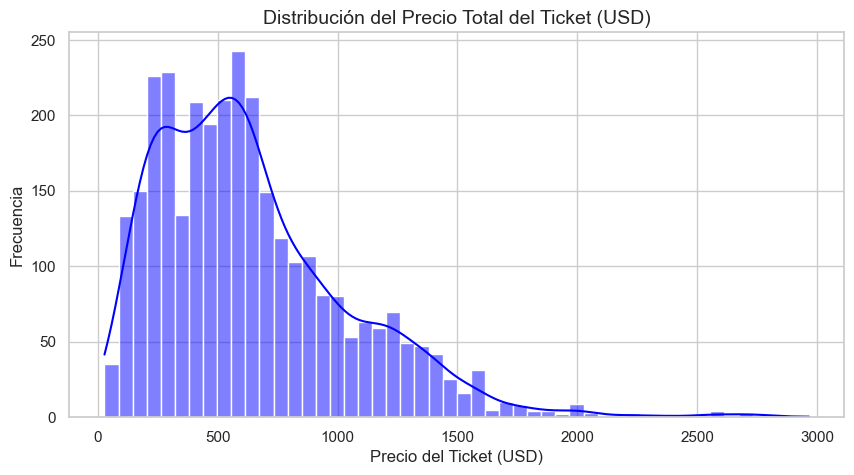

In [15]:

plt.figure(figsize=(10, 5))
sns.histplot(df['total_ticket_price_usd'], bins=50, kde=True, color='blue')
plt.title('Distribución del Precio Total del Ticket (USD)', fontsize=14)
plt.xlabel('Precio del Ticket (USD)')
plt.ylabel('Frecuencia')
plt.savefig('../results/plots/Distr_precio_total_ticket.png', dpi=300, bbox_inches='tight')
plt.show()


### Impacto de las fases de conflicto
cómo las distintas fases del conflicto afectan los costos de combustible.

C:\Users\diego\AppData\Local\Temp\ipykernel_37640\854609733.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='conflict_phase', y='total_fuel_cost_usd', palette='Set2')


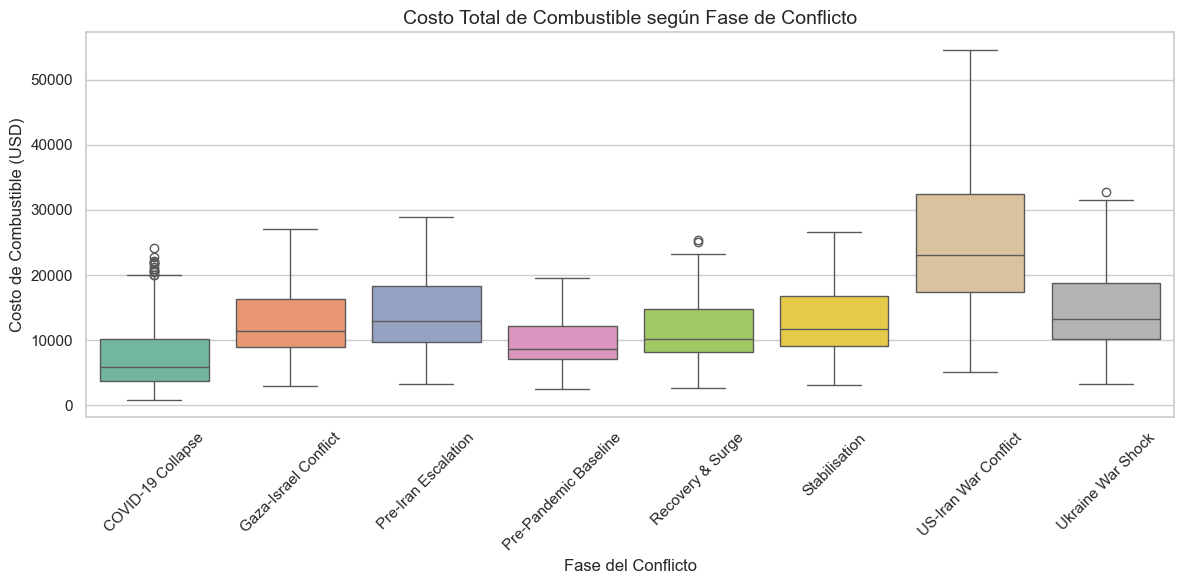

In [16]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='conflict_phase', y='total_fuel_cost_usd', palette='Set2')
plt.title('Costo Total de Combustible según Fase de Conflicto', fontsize=14)
plt.xlabel('Fase del Conflicto')
plt.ylabel('Costo de Combustible (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../results/plots/costos_segun_fase_conflicto.png', dpi=300, bbox_inches='tight')
plt.show()

### Mapa de Correlaciones
Mapa de calor para identificar colinealidad y variables fuertemente correlacionadas con nuestra variable objetivo

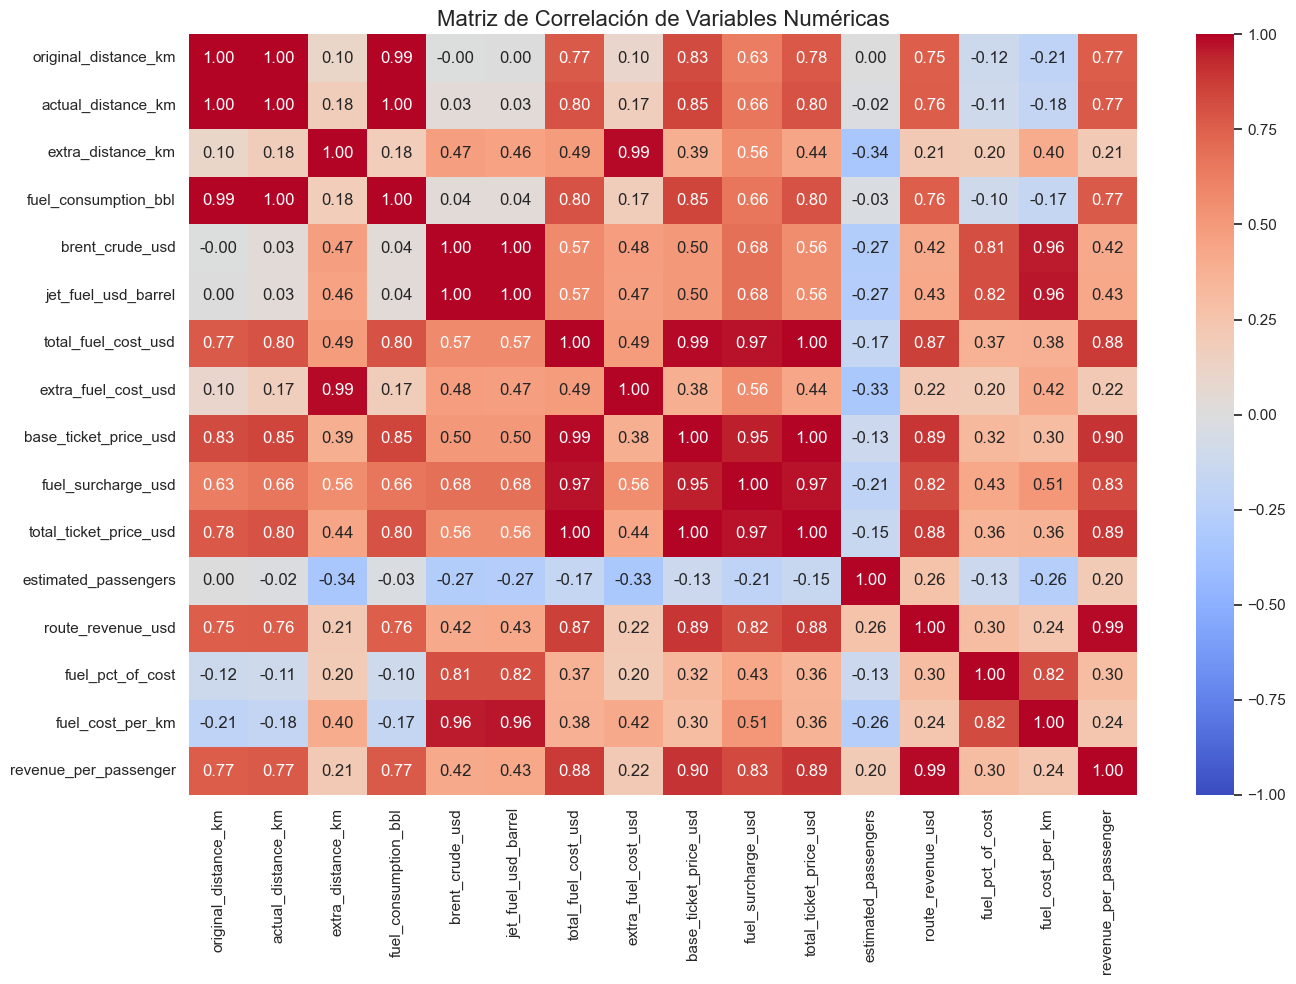

In [17]:
# Seleccionar solo las columnas numéricas para la correlación
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(14, 10))
correlation_matrix = df[num_cols].corr()

# Crear un mapa de calor con anotaciones
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlación de Variables Numéricas', fontsize=16)
plt.tight_layout()

plt.savefig('../results/plots/Matriz_de_Correlación.png', dpi=300, bbox_inches='tight')

plt.show()

### Aprendizaje No Supervisado: Reducción de Dimensionalidad y Clustering. Escalamos los datos numéricos, ya que algoritmos como PCA y K-Means son sensibles a la magnitud de las variables.

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. Seleccionar solo variables numéricas y rellenar nulos si los hubiera
num_data = df.select_dtypes(include=['float64', 'int64']).fillna(0)

# 2. Escalar los datos (media 0, varianza 1)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(num_data)

### Aplicando PCA (Reducción de Dimensionalidad)
Aplicamos Principal Component Analysis (PCA) para reducir la dimensionalidad a 2 componentes principales y visualizar la varianza de nuestros datos.

Varianza explicada por los 2 componentes: 80.65%


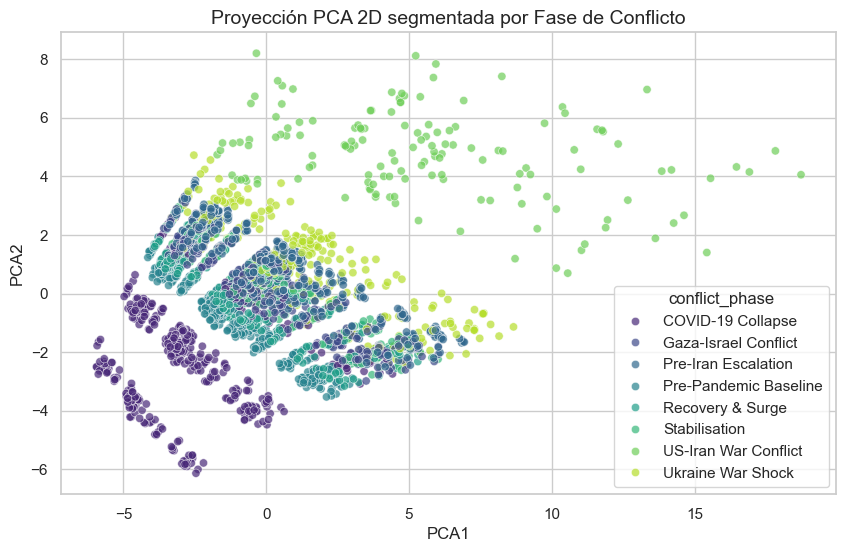

In [19]:
# Aplicar PCA para reducir a 2 dimensiones
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

# Añadir los resultados al DataFrame para graficar
df['PCA1'] = pca_result[:, 0]
df['PCA2'] = pca_result[:, 1]

# Ver cuánta información retienen estos 2 componentes
varianza_explicada = pca.explained_variance_ratio_.sum() * 100
print(f"Varianza explicada por los 2 componentes: {varianza_explicada:.2f}%")

# Gráfico de PCA
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='conflict_phase', data=df, palette='viridis', alpha=0.7)
plt.title('Proyección PCA 2D segmentada por Fase de Conflicto', fontsize=14)
plt.savefig('../results/plots/Proyeccion_pca_fase_conflicto.png', dpi=300, bbox_inches='tight')
plt.show()

### Aplicando K-Means (Clustering)
Aplicamos el algoritmo K-Means para descubrir agrupaciones inherentes en los vuelos basándonos en sus características numéricas.

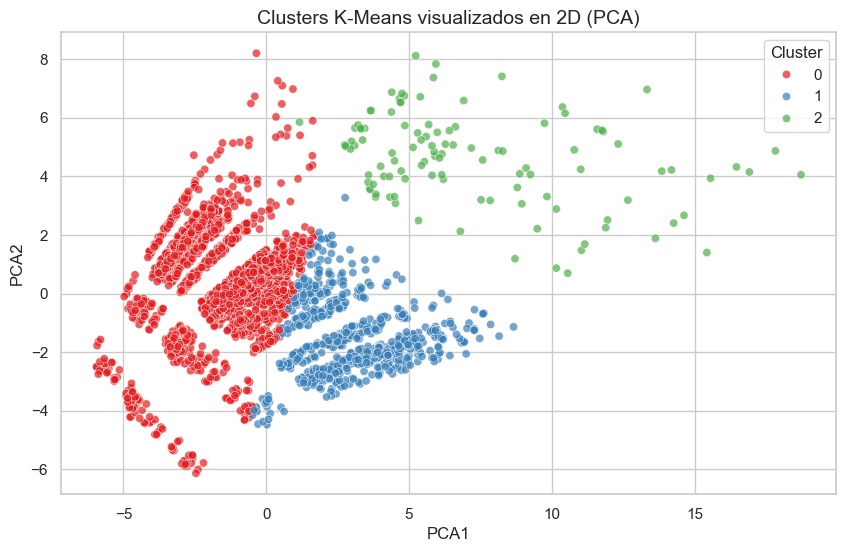

In [20]:
# Aplicar K-Means (elegimos 3 clusters como ejemplo)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(scaled_data)

# Visualizar los clusters sobre la proyección PCA
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', palette='Set1', data=df, alpha=0.7)
plt.title('Clusters K-Means visualizados en 2D (PCA)', fontsize=14)
plt.show()

### Aplicando K-Means (Clustering) y Justificación

Para la etapa de Aprendizaje No Supervisado, aplicaremos el algoritmo **K-Means**. 

**Justificación de los 3 clústeres:**
1. **Perspectiva de Negocio:** Segmentar las rutas aéreas en 3 grupos nos permite clasificar los vuelos en perfiles operativos lógicos (por ejemplo: vuelos de corto, medio y largo alcance), lo cual facilita la toma de decisiones estratégicas respecto a los costos.
2. **Perspectiva Técnica:** Al observar la proyección previa de PCA, notamos que a medida que aumenta la magnitud del vuelo, los datos tienden a separarse o bifurcarse. Se utilizará la métrica **Silhouette Score** para validar matemáticamente que la cohesión interna de estos 3 grupos es sólida y que están bien diferenciados entre sí.

Silhouette Score para 3 clusters: 0.421


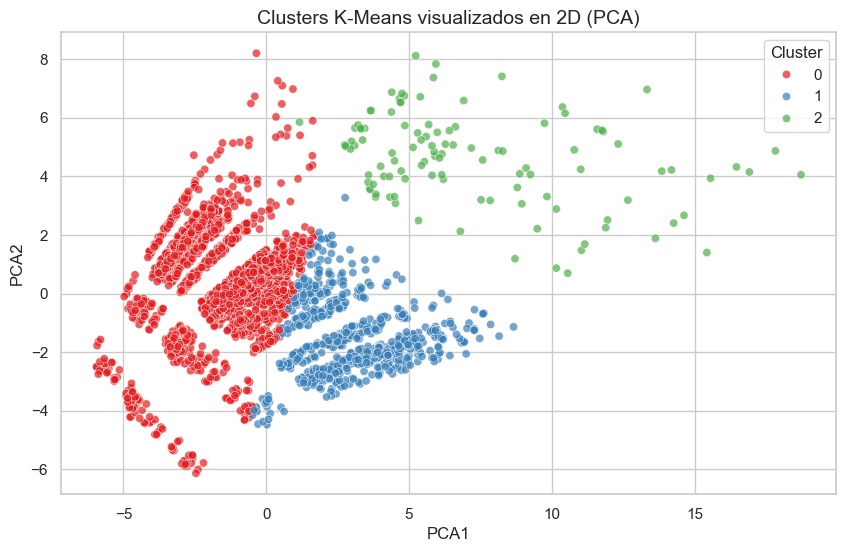


--- Perfil de los Clusters (Promedios) ---


,original_distance_km,total_fuel_cost_usd,total_ticket_price_usd,fuel_cost_per_km
Cluster,,,,
0,4526.56,8371.84,428.62,1.96
1,9864.54,19163.84,1088.62,1.98
2,7112.08,28324.45,1508.61,3.52


In [21]:
import os
from sklearn.metrics import silhouette_score

# Asegurarnos de que la carpeta de resultados exista
os.makedirs('../results/plots', exist_ok=True)

# 1. Aplicar K-Means con 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(scaled_data)

# 2. Calcular Silhouette Score para justificar técnicamente el modelo
sil_score = silhouette_score(scaled_data, df['Cluster'])
print(f"Silhouette Score para 3 clusters: {sil_score:.3f}")
# (Un valor más cerca de 1 indica clusters bien definidos)

# 3. Visualizar y guardar el gráfico de PCA con Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', palette='Set1', data=df, alpha=0.7)
plt.title('Clusters K-Means visualizados en 2D (PCA)', fontsize=14)

# Guardar el gráfico ANTES de plt.show()
plt.savefig('../results/plots/kmeans_pca_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Resumen descriptivo de los Clusters
print("\n--- Perfil de los Clusters (Promedios) ---")
# Seleccionamos variables clave para entender qué significa cada grupo
columnas_resumen = ['original_distance_km', 'total_fuel_cost_usd', 'total_ticket_price_usd', 'fuel_cost_per_km']
resumen_clusters = df.groupby('Cluster')[columnas_resumen].mean().round(2)
display(resumen_clusters)

### Exportacion de datos
Finalmente, exportamos el dataset procesado con las nuevas métricas y etiquetas de clustering

In [23]:
# Guardar el DataFrame procesado en la carpeta data/
ruta_exportacion = '../data/route_cost_processed.csv'
df.to_csv(ruta_exportacion, index=False)

print(f"Dataset limpio y guardado exitosamente en: {ruta_exportacion}")

Dataset limpio y guardado exitosamente en: ../data/route_cost_processed.csv


---
## Conclusión de la Fase Exploratoria y Entregables


1. **`src/data_preprocessing.py`**: Pipeline modularizado con las funciones de limpieza, optimización de tipos de memoria e ingeniería de características (creación de métricas de eficiencia).
2. **`results/plots/`**: Carpeta con visualizaciones (PNG) que respaldan los hallazgos de distribución, correlación y segmentación (K-Means/PCA), listas para el Informe Técnico final.
3. **`data/processed/route_cost_processed.csv`**: El dataset limpio, con nuevas variables y etiquetado con clústeres. 

**El encargado del notebook `02_supervised_modeling.ipynb` deberá importar directamente el archivo `route_cost_processed.csv` para entrenar y evaluar los modelos de regresión, omitiendo la necesidad de repetir el preprocesamiento.**